In [28]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.stats import kstest, expon
import time
from numba import njit
import pandas as pd
import pickle as pkl
import copy
import random
import importlib
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, BoundaryNorm
from matplotlib.colors import ListedColormap
import seaborn as sns
from collections import defaultdict
np.set_printoptions(threshold=np.inf)
import pickle

In [29]:
def cumulative_rate_by_neuron(trial, total_time, num_time_points=100):
    time_points = np.linspace(0.01, total_time, num_time_points)  # Avoid t=0
    neuron_cumulative_rates = {}

    # Group spikes by neuron
    neuron_spikes = defaultdict(list)
    for spike_time, neuron_id in trial:
        neuron_spikes[neuron_id].append(spike_time)

    # Compute cumulative rate for each neuron
    for neuron_id, spikes in neuron_spikes.items():
        spikes = sorted(spikes)
        cumulative_counts = np.zeros(len(time_points))
        idx = 0  # Index to track spikes

        # Efficiently count spikes up to each time point
        for i, t in enumerate(time_points):
            while idx < len(spikes) and spikes[idx] <= t:
                idx += 1
            cumulative_counts[i] = idx

        cumulative_rate = cumulative_counts / time_points  # N(t) / t
        neuron_cumulative_rates[neuron_id] = cumulative_rate

    return time_points, neuron_cumulative_rates


def cumulative_rate_for_process(trial, total_time, num_time_points=100):
    time_points = np.linspace(0.01, total_time, num_time_points)  # Avoid t=0
    spike_times = sorted(spike_time for spike_time, _ in trial)

    cumulative_counts = np.zeros(len(time_points))
    idx = 0  # Index to track spikes

    # Efficiently count spikes up to each time point
    for i, t in enumerate(time_points):
        while idx < len(spike_times) and spike_times[idx] <= t:
            idx += 1
        cumulative_counts[i] = idx

    cumulative_rate = cumulative_counts / time_points  # N(t) / t
    return time_points, cumulative_rate

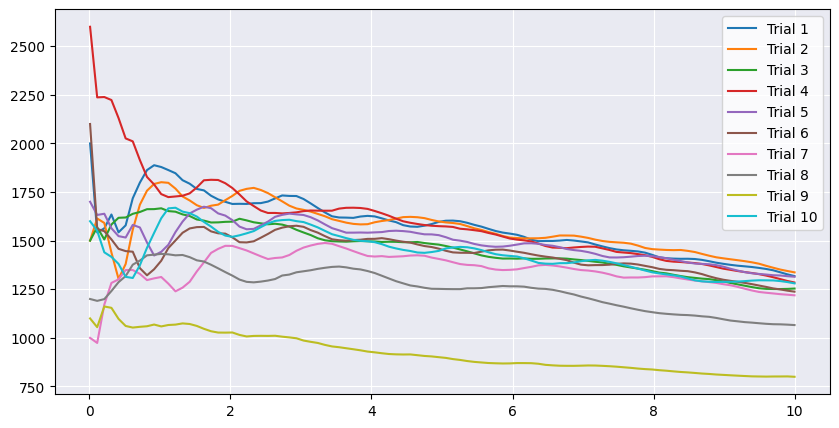

In [34]:
# Import 10 trials

trial_indexes = range(1, 11)

#print(f'Read data')
trials = dict()
n_times = np.zeros(250)
for trial in trial_indexes:
    #print(f'Trial {trial}')

    df = pd.read_csv(f'neuronal_data/{trial}.csv', index_col=0)
    path = []
    for mark, id in enumerate(df.index):
        times = df.loc[id][df.loc[id] > 0].values
        # print(f' Neuron {id} ({len(times)} times)')
        path.extend(list(zip(times, np.ones_like(times, dtype=int)*(mark+1))))
        n_times[mark] += len(times)

    path = sorted(path, key=lambda x: x[0])
    path = [(t-path[0][0], m) for t, m in path]
    trials[trial] = path

fig,ax=plt.subplots(figsize=(10,5))

for index in trial_indexes:
    trial_data = [(t,m) for t,m in trials[index] if t<10]
    max_time = trial_data[-1][0]
    time_points_total, cumulative_rate_total = cumulative_rate_for_process(trial_data, max_time)
    ax.plot(time_points_total, cumulative_rate_total, label=f'Trial {index}')
    ax.set_facecolor("#e9eaf2")
    ax.grid(color='white')

plt.legend()
plt.show()

In [2]:
# Code for generating resampled trials

trial_indexes = range(1, 11)

#print(f'Read data')
trials = dict()
n_times = np.zeros(250)
for trial in trial_indexes:
    #print(f'Trial {trial}')

    df = pd.read_csv(f'neuronal_data/{trial}.csv', index_col=0)
    path = []
    for mark, id in enumerate(df.index):
        times = df.loc[id][df.loc[id] > 0].values
        # print(f' Neuron {id} ({len(times)} times)')
        path.extend(list(zip(times, np.ones_like(times, dtype=int)*(mark+1))))
        n_times[mark] += len(times)

    path = sorted(path, key=lambda x: x[0])
    path = [(t-path[0][0], m) for t, m in path]
    trials[trial] = path

# print('Summary')
# for j in range(250):
#     print(f'Suprocess {j+1} (Neuron {j+1}): {int(n_times[j])} times')

print(f'Keep trials with less that 10 non-active neurons')
n_jumps = dict()
sub_trials = dict()
for key, values in trials.items():
    n_jumps[key] = np.ones(250)
    for j in range(1, 251):  # Marks
        times = [t for t, m in values if m==j]
        n_jumps[key][j-1] = len(times)

    #print(f'Trial {key}')
    #print(f'   Number of non-jumping neurons: {np.sum(n_jumps[key]==0)}')
    if np.sum(n_jumps[key]==0) < 10:
        #print('   Keep trial')
        sub_trials[key] = trials[key]
    #print(f'   Maximal number of jumps: {np.max(n_jumps[key])}')

#print(f'Count jumps')
min_jumps = np.ones(250) * 1e8
max_jumps = np.zeros(250)
for key, values in sub_trials.items():
    #print(f'Trial {key}')
    for j in range(1, 251):  # Marks
        times = [t for t, m in values if m==j]
        min_jumps[j-1] = np.fmin(min_jumps[j-1], len(times))
        max_jumps[j-1] = np.fmax(max_jumps[j-1], len(times))
        #if len(times) == 0:
            #print(f'Neuron {j} has {len([t for t, m in values if m==j])} jumps')

# # Plot min/max jumps per neuron
# ind = np.argsort(min_jumps)
# plt.figure(figsize=(20, 10))
# plt.plot(min_jumps[ind], label='Min number of jumps')
# plt.plot(max_jumps[ind], label='Max number of jumps')
# plt.legend()
# plt.show()

n_min = 50
print(f'Keep neurons with at least {n_min} jumps')
for key, values in sub_trials.items():
    sub_trials[key] = [(t, m) for t, m in values if min_jumps[m-1] >= n_min]
keeped_neurons = np.unique([m for t, m in sub_trials[key]])
print(f'Kept neurons: {keeped_neurons} ({len(keeped_neurons)})')

# # Plot data and mean intensities
# max_time = 0
# for key, values in sub_trials.items():
#     print(f'Trial {key}')
#     # for j in range(1, 251):  # Marks
#     #     print(f'Neuron {j} has {len([t for t, m in values if m==j])} times')
#
#     max_time = np.fmax(max_time, np.array(values)[:, 0].max())
#     plt.figure(figsize=(20, 20))
#     for j in keeped_neurons:  # Marks
#         times = [t for t, m in values if m==j]
#         plt.scatter(times, np.ones_like(times)*j)
#     plt.title(f'Trial {key}')
#     plt.show()
#
# for key, values in sub_trials.items():
#     print(f'Trial {key}')
#     # for j in range(1, 251):  # Marks
#     #     print(f'Neuron {j} has {len([t for t, m in values if m==j])} times')
#     plt.figure(figsize=(20, 20))
#     for j in keeped_neurons:  # Marks
#         times = [t for t, m in values if m == j]
#         plt.plot(np.r_[times, max_time], np.r_[np.cumsum(np.ones_like(times)) / times, len(times) / max_time])  # + np.ones_like(times) * j)
#         plt.plot(times[-1], len(times) / times[-1], 'k*')
#     plt.title(f'Trial {key}')
#     plt.ylim(0, 60)
#     plt.show()

# for key, values in n_jumps.items():
#     print(f'Trial {key}: {np.argsort(values)[::-1][:5]}')

time_cut = 10
print(f'Cut time at {time_cut}')
for key, values in sub_trials.items():
    print(f'Trial {key}')
    sub_trials[key] = [(t, m) for t, m in values if t <= time_cut]

print('Data is in sub_trials')



# rewrite 


new_trial_indexes = [key for key, values in sub_trials.items()]

new_trials = {}
for trial in new_trial_indexes:
    #print(f'Trial {trial}')
    filtered_data = sub_trials[trial]  

    path = []
    for mark, neuron_id in enumerate(keeped_neurons):
        times = [time for time, n_id in filtered_data if n_id == neuron_id]
        #print(f' Neuron {mark} or {neuron_id} ({len(times)} times)')
        path.extend([(time, mark ) for time in times])

    path = sorted(path, key=lambda x: x[0])
    #path = [(t - path[0][0], m ) for t, m in path]

    if path and path[0][0] == 0:
        path = path[1:]

    new_trials[trial] = path


# resampling

nb_samples = 25
nb_processes = 3

resampled_trial_indexes = np.arange(nb_samples)
resampled_trials = [ [] for _ in range(nb_samples)]

for k in range(nb_samples):
    indexes = random.sample(new_trial_indexes, nb_processes)
    s = 0
    for j in indexes:
        resampled_trials[k] += [(t+s,m) for t,m in new_trials[j]]
        s = resampled_trials[k][-1][0]

trials = [new_trials[i] for i in new_trial_indexes]

Keep trials with less that 10 non-active neurons
Keep neurons with at least 50 jumps
Kept neurons: [  4   5  16  23  28  40  41  46  47  48  49  50  51  60  64  65  68  69
  75  76  78  80  81  84  93  94 100 104 107 111 113 114 120 127 142 143
 149 155 157 165 168 170 173 178 184 187 188 200 205 207 211 215 216 218
 219 222 223 231 235 238 248] (61)
Cut time at 10
Trial 1
Trial 2
Trial 4
Trial 5
Trial 6
Trial 7
Trial 10
Data is in sub_trials


In [30]:
with open("scripts_and_data/7_trials.txt", "r") as file:
    file_content = file.read()
exec(file_content)

# trials : contains original 7 trials

with open("scripts_and_data/data_61.txt", "r") as file:
    file_content = file.read()
exec(file_content)

# resampled trials : contains 25 resampled trials of the 7 original ones on [0,10]

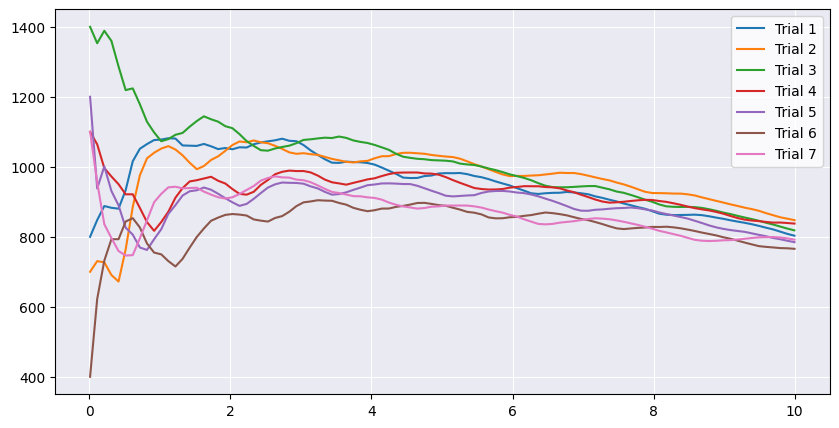

In [31]:
fig,ax=plt.subplots(figsize=(10,5))

for index in range(7):
    trial_data = trials[index]
    max_time = trial_data[-1][0]
    time_points_total, cumulative_rate_total = cumulative_rate_for_process(trial_data, max_time)
    ax.plot(time_points_total, cumulative_rate_total, label=f'Trial {index+1}')
    ax.set_facecolor("#e9eaf2")
    ax.grid(color='white')

plt.legend()
plt.show()

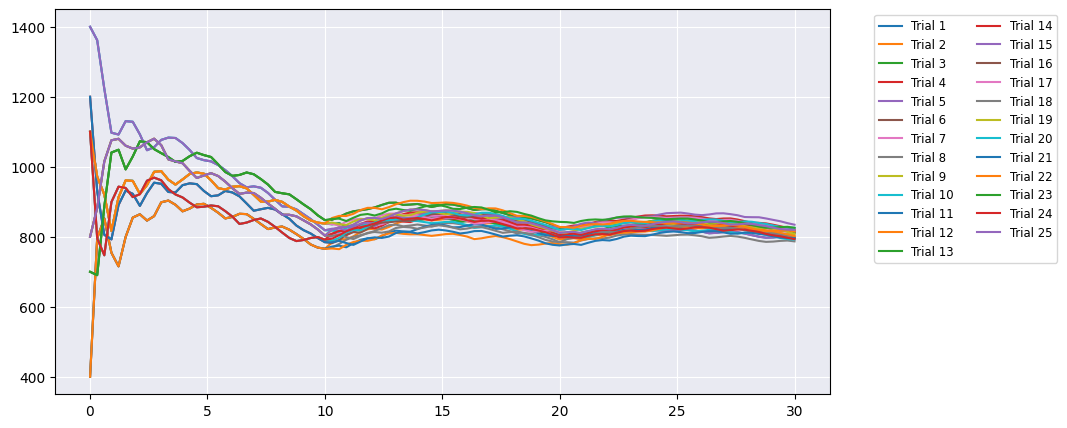

In [32]:
fig,ax=plt.subplots(figsize=(10,5))

for index in range(25):
    trial_data = resampled_trials[index]
    max_time = trial_data[-1][0]
    time_points_total, cumulative_rate_total = cumulative_rate_for_process(trial_data, max_time)
    ax.plot(time_points_total, cumulative_rate_total, label=f'Trial {index+1}')
    ax.set_facecolor("#e9eaf2")
    ax.grid(color='white')

#plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.show()